# Main Figure 2: AGIST benchmark

This notebook reproduces a's snapshots, b and e. The c/d comparisons require
two missing generator files: `attn_matrix_time0.npy` and `g_values.npy`.

Evaluate the model, reconstruct its velocity display and calculate ten-replicate
distances. The predicted attention and growth are calculated too; the c/d cells
complete their comparisons when the two reference files are supplied.

Run these cells with the CytoBridge code folder available. The AGIST download
provides observations, model and edge predictor.
Choose a new `CYTOBRIDGE_RUN_LABEL` for a new simulation.

In [1]:
import os
import sys
import subprocess
from pathlib import Path

import CytoBridge as cb
from IPython.display import Image, display

project = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
device = os.environ.get("CYTOBRIDGE_DEVICE", "cuda")
run_name = os.environ.get("CYTOBRIDGE_RUN_LABEL", "reader_run")
repo = Path(cb.__file__).resolve().parents[1]

def run(module, *arguments):
    subprocess.run([sys.executable, "-m", module, *map(str, arguments)],
                   cwd=repo, check=True)

agist_root = Path(os.environ.get("CYTOBRIDGE_AGIST_DATA", project / "data/agist"))
if not (agist_root / "model/model_final").is_file():
    cb.datasets.download("agist", destination=project)
output = project / "outputs" / ("main_figure_2_" + run_name)
output.mkdir(parents=True, exist_ok=False)
figures = output / "figures"

def show_calculated(path, width=720):
    if Path(path).suffix == ".pdf":
        import pymupdf
        with pymupdf.open(path) as document:
            display(Image(data=document[0].get_pixmap(matrix=pymupdf.Matrix(1.5, 1.5)).tobytes("png"), width=width))
    else:
        display(Image(filename=str(path), width=width))

## a. Draw the four simulated snapshots

The original CSV already contains the generator's four sampled populations.
Plot the spatial coordinates, with every second cell displayed as in the
original plotting code. The upper brain/embryo illustration is a hand-drawn
schematic and does not require model output.

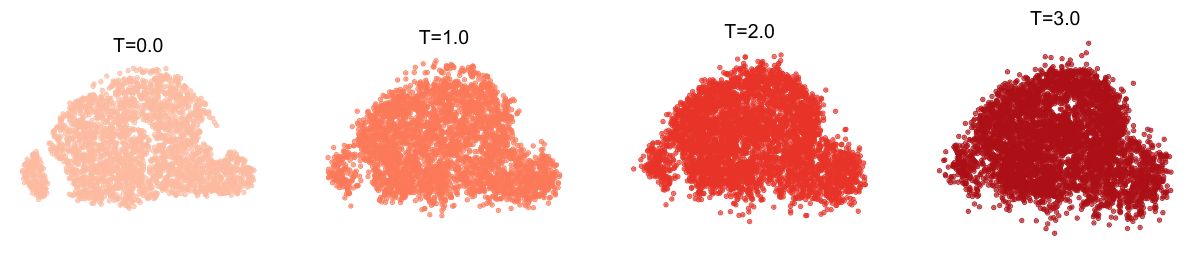

In [2]:
import pandas as pd
from reproduction.agist.main_figure import draw_observed_snapshots

observed = pd.read_csv(agist_root / "mouse_brain_simulation.csv")
snapshot_pdf = draw_observed_snapshots(observed, figures)
show_calculated(snapshot_pdf)

## b. Evaluate the velocity and calculate its displayed projection

Evaluate intrinsic drift, interaction and score gradient on the observed
cells. Sum them and compare with the saved generator fields. The original
display uses the same seed-0 30% sample for prediction and reference,
30-neighbor graphs, then scVelo velocity projection. The physical plot uses
T=0; the gene plot uses all times and the first two gene-state coordinates.
The `X_umap` name in scVelo is only a display key here, not a fitted UMAP.

  0%|          | 0/9544 [00:00<?, ?cells/s]

  0%|          | 0/9544 [00:00<?, ?cells/s]

  0%|          | 0/1506 [00:00<?, ?cells/s]

  0%|          | 0/1506 [00:00<?, ?cells/s]

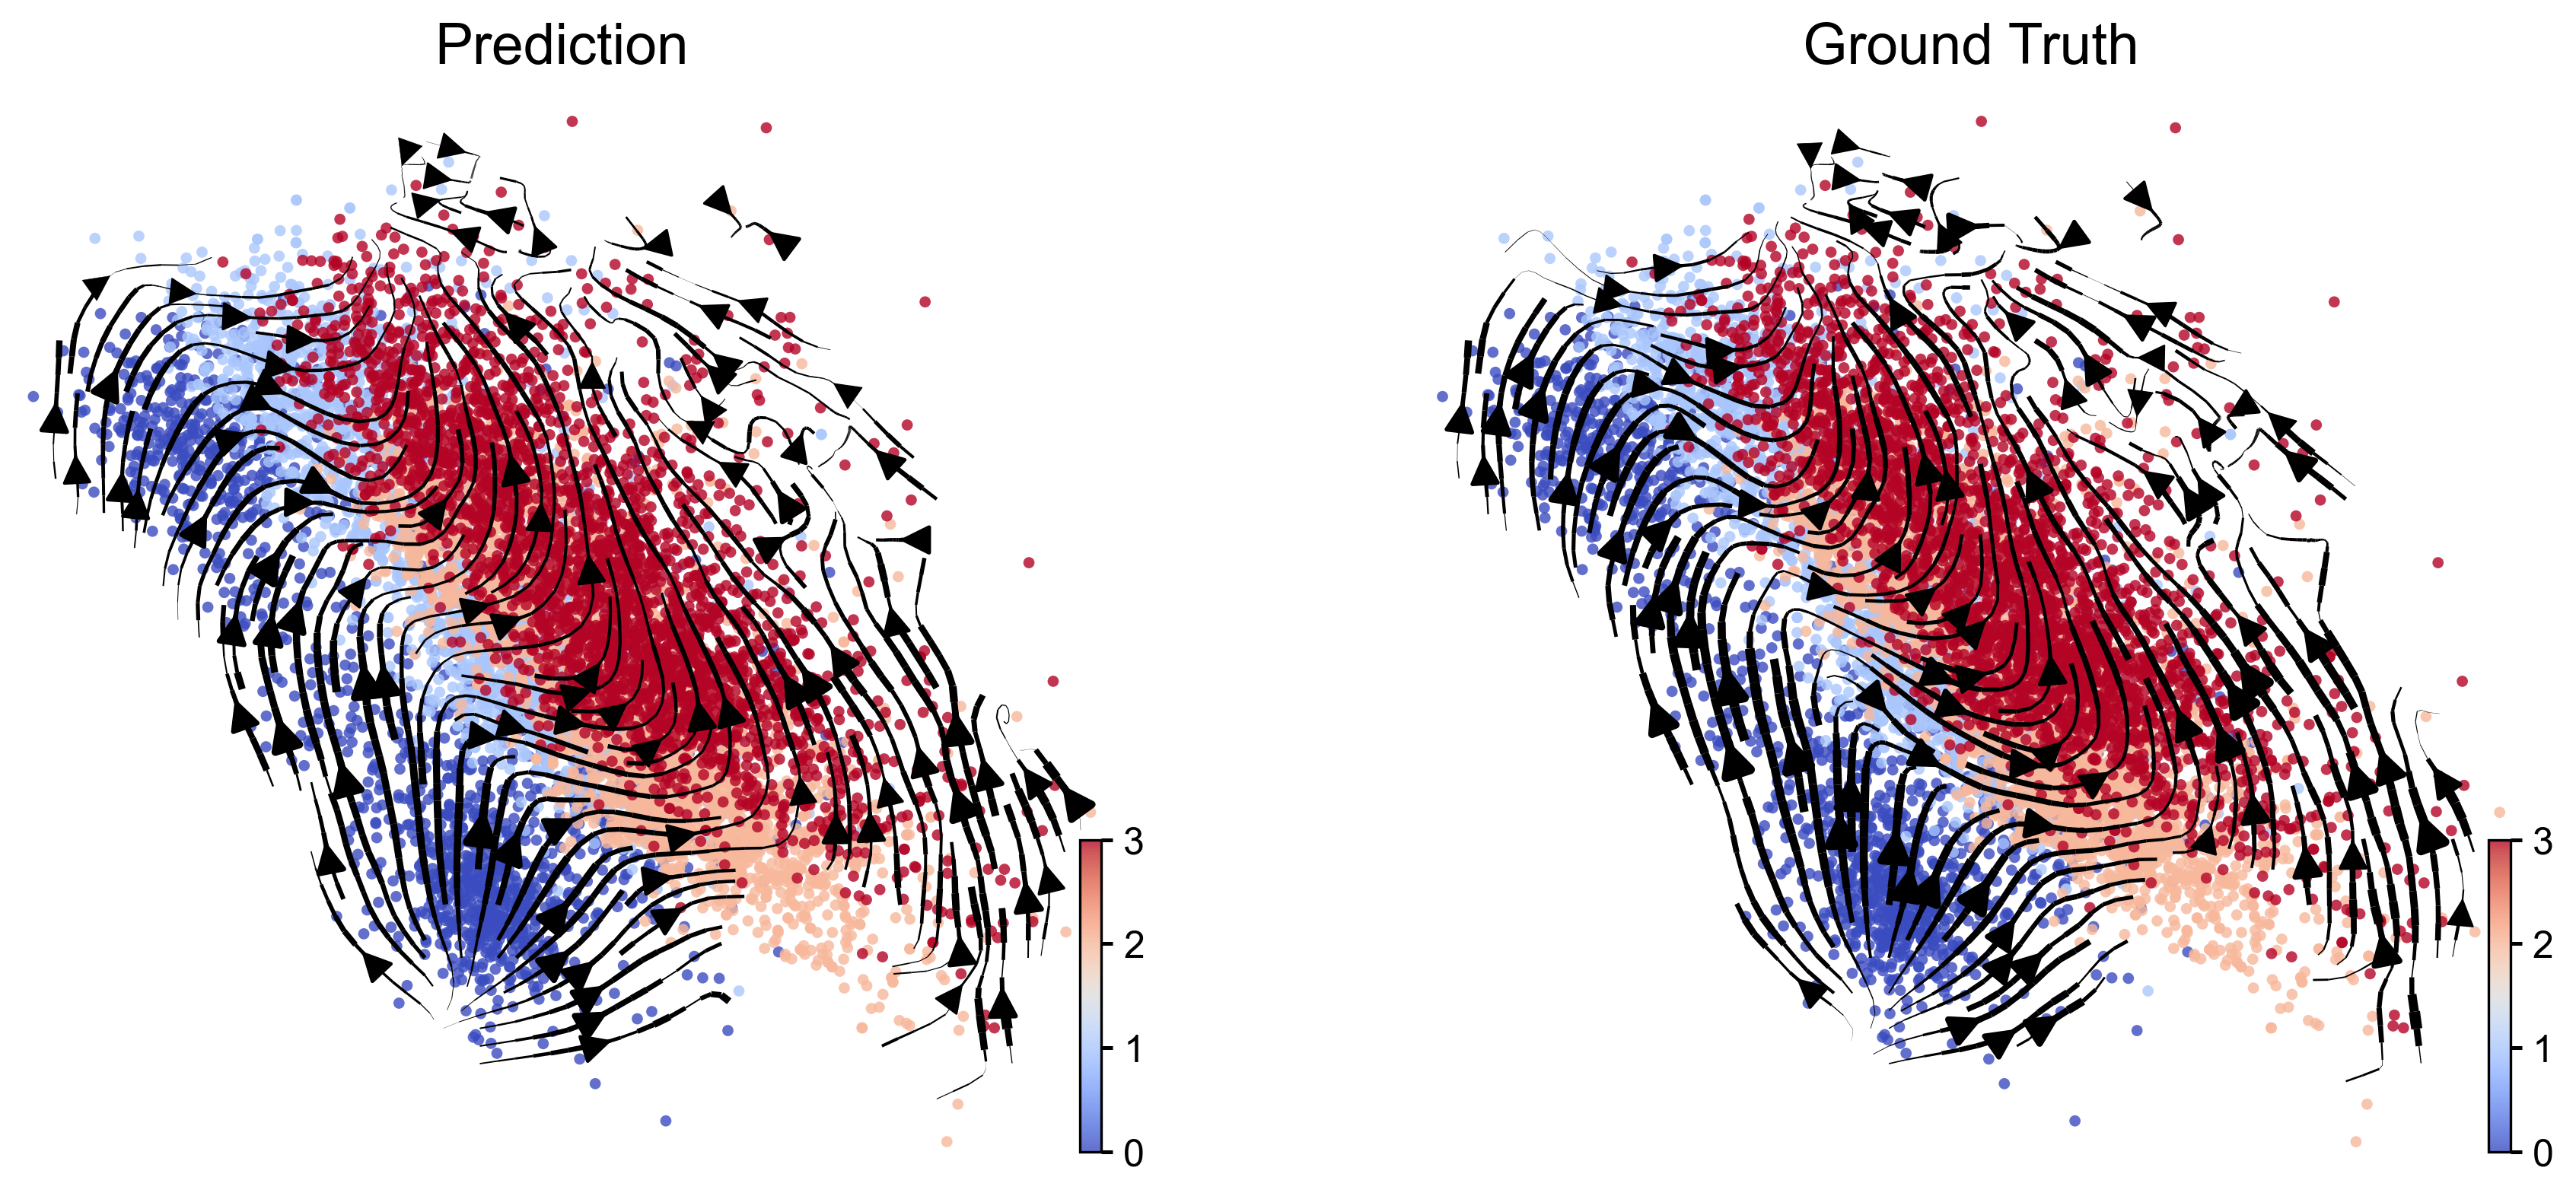

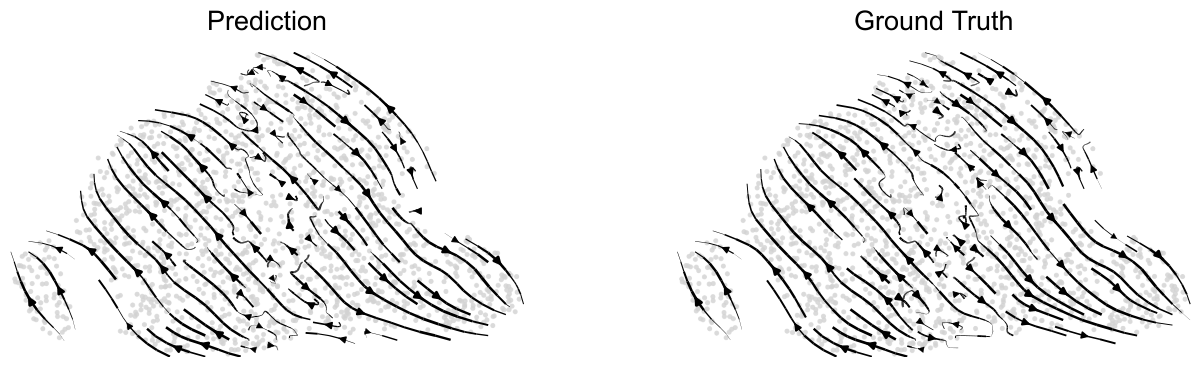

In [3]:
import numpy as np
from reproduction.agist.inputs import evaluate_velocity
from reproduction.agist.main_figure import calculate_velocity_display, draw_velocity_display

observed, predicted = evaluate_velocity(
    agist_root / "mouse_brain_simulation.csv", agist_root / "config.yaml",
    agist_root / "model", agist_root / "edge_classifier/mouse.pt",
    device=device, seed=42)
np.savez_compressed(output / "model_velocity.npz", **predicted)
velocity_display = calculate_velocity_display(
    observed, predicted, agist_root / "figure_fields/figure_fields.npz",
    output / "velocity_display", n_jobs=4)
velocity_figures = draw_velocity_display(velocity_display, figures)
for space, path in velocity_figures.items():
    print(space)
    show_calculated(path)

## c/d. Calculate attention and growth, then compare with generator truth

The c calculation uses all time-zero cells in one graph, not the random
groups used for simulation. It averages the absolute first-layer attention
over eight heads, sums outgoing edges, and forms the original 50×50 flow grid
from the top 5,000 positive edges. Sparse edges avoid storing a dense matrix.
The d calculation evaluates growth on every observed cell, independently
clips each distribution at its 1st/99th percentiles, and fits the regression.

Put the original generator files
in `data/agist/generator_reference/`, or set `CYTOBRIDGE_AGIST_GENERATOR_REFERENCE`
to their directory. They were produced by the generator checkpoint used for
these simulated observations.

In [4]:
from reproduction.agist.main_figure import (
    evaluate_growth_attention, calculate_attention_display,
    draw_attention_display, draw_growth_correlation,
)

growth, attention_edges = evaluate_growth_attention(
    agist_root / "mouse_brain_simulation.csv", agist_root / "config.yaml",
    agist_root / "model", agist_root / "edge_classifier/mouse.pt",
    output / "growth_attention", device=device)
coordinates_t0 = observed.loc[observed["samples"].eq(0), ["x1", "x2"]].to_numpy()
predicted_attention = calculate_attention_display(attention_edges, coordinates_t0)
np.savez_compressed(output / "predicted_attention_display.npz", **predicted_attention)
reference = Path(os.environ.get("CYTOBRIDGE_AGIST_GENERATOR_REFERENCE",
                               agist_root / "generator_reference"))
required = [reference / "attn_matrix_time0.npy", reference / "g_values.npy"]
missing = [path for path in required if not path.is_file()]
if missing:
    display({
        "c/d comparison": "Not drawn: matching generator inputs are unavailable",
        "missing files": [str(path) for path in missing],
        "calculated growth values": len(growth),
        "calculated attention edges": len(attention_edges["attention"]),
    })
else:
    truth_attention = calculate_attention_display(
        np.load(required[0], allow_pickle=False), coordinates_t0)
    attention_pdf = draw_attention_display(
        coordinates_t0, predicted_attention, truth_attention, figures)
    growth_pdf, growth_metrics = draw_growth_correlation(
        growth, np.load(required[1], allow_pickle=False), figures)
    show_calculated(attention_pdf)
    show_calculated(growth_pdf)
    display(growth_metrics)

{'c/d comparison': 'Not drawn: matching generator inputs are unavailable',
 'missing files': ['/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/data/agist/generator_reference/attn_matrix_time0.npy',
  '/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/data/agist/generator_reference/g_values.npy'],
 'calculated growth values': 31816,
 'calculated attention edges': 33356}

## e. Simulate ten independently seeded populations

The checkpoint and time-zero observations remain fixed. The seeds vary the
interaction grouping, Brownian increments and cell birth/loss draws.
The original settings are dt=0.1, sigma=0.03, group size 1,024 and zero
daughter displacement.

To evaluate previously generated populations, set
`CYTOBRIDGE_AGIST_TRAJECTORIES` to their `trajectories` directory.
This reuses trajectories, not distances or a finished figure.

In [5]:
trajectory_override = os.environ.get("CYTOBRIDGE_AGIST_TRAJECTORIES")
distance_override = os.environ.get("CYTOBRIDGE_AGIST_DISTANCES")
if distance_override:
    trajectories = None  # Reuse explicitly selected complete W2 evaluation.
elif trajectory_override:
    trajectories = Path(trajectory_override)
else:
    simulation = output / "simulation"
    run("scripts.run_agist_split_sde_replicates",
        "--config", agist_root / "config.yaml",
        "--checkpoint-dir", agist_root / "model",
        "--edge-predictor", agist_root / "edge_classifier/mouse.pt",
        "--data-csv", agist_root / "mouse_brain_simulation.csv",
        "--output-dir", simulation, "--simulate-only", "--device", device)
    trajectories = simulation / "trajectories"

## e. Calculate the weighted distances in the original coordinate spaces

Read the populations above, calculate W2 at times 1, 2 and 3 in the two
spatial coordinates and all 50 gene coordinates, then summarize the ten
replicates as means and sample standard deviations. This is exact transport
on the full populations and can take tens of minutes on CPU.

For a previously completed calculation, `CYTOBRIDGE_AGIST_DISTANCES` may point
to its distance directory. That explicit choice reuses numeric evaluation
results; leaving it unset runs the calculation below.

In [6]:
if distance_override:
    distances = Path(distance_override)
else:
    distances = output / "distances"
    run("scripts.evaluate_and_plot_agist_w2_replicates",
        "--trajectory-dir", trajectories,
        "--truth-csv", agist_root / "mouse_brain_simulation.csv",
        "--output-dir", distances)

## e. Draw the newly selected distance calculation

The CytoBridge values are read from `distances`. STORIES and stVCR use the
paper's recorded external benchmark values.

,space,time,mean_w2,sd_w2,n,min_w2,max_w2,mean_n_predicted,sd_n_predicted,se_w2,ci95_halfwidth
0,gene,1,1.000585,0.004713,10,0.995648,1.011058,7312.5,33.814034,0.001491,0.003372
1,gene,2,1.179081,0.003420,10,1.174406,1.185135,9429.1,53.463279,0.001081,0.002447
2,gene,3,1.281960,0.003516,10,1.277129,1.288442,10083.0,65.613346,0.001112,0.002515
3,physical,1,0.022481,0.000343,10,0.021966,0.023067,7312.5,33.814034,0.000108,0.000245
4,physical,2,0.026083,0.001093,10,0.025099,0.028882,9429.1,53.463279,0.000346,0.000782
5,physical,3,0.028520,0.001439,10,0.027263,0.031785,10083.0,65.613346,0.000455,0.001029


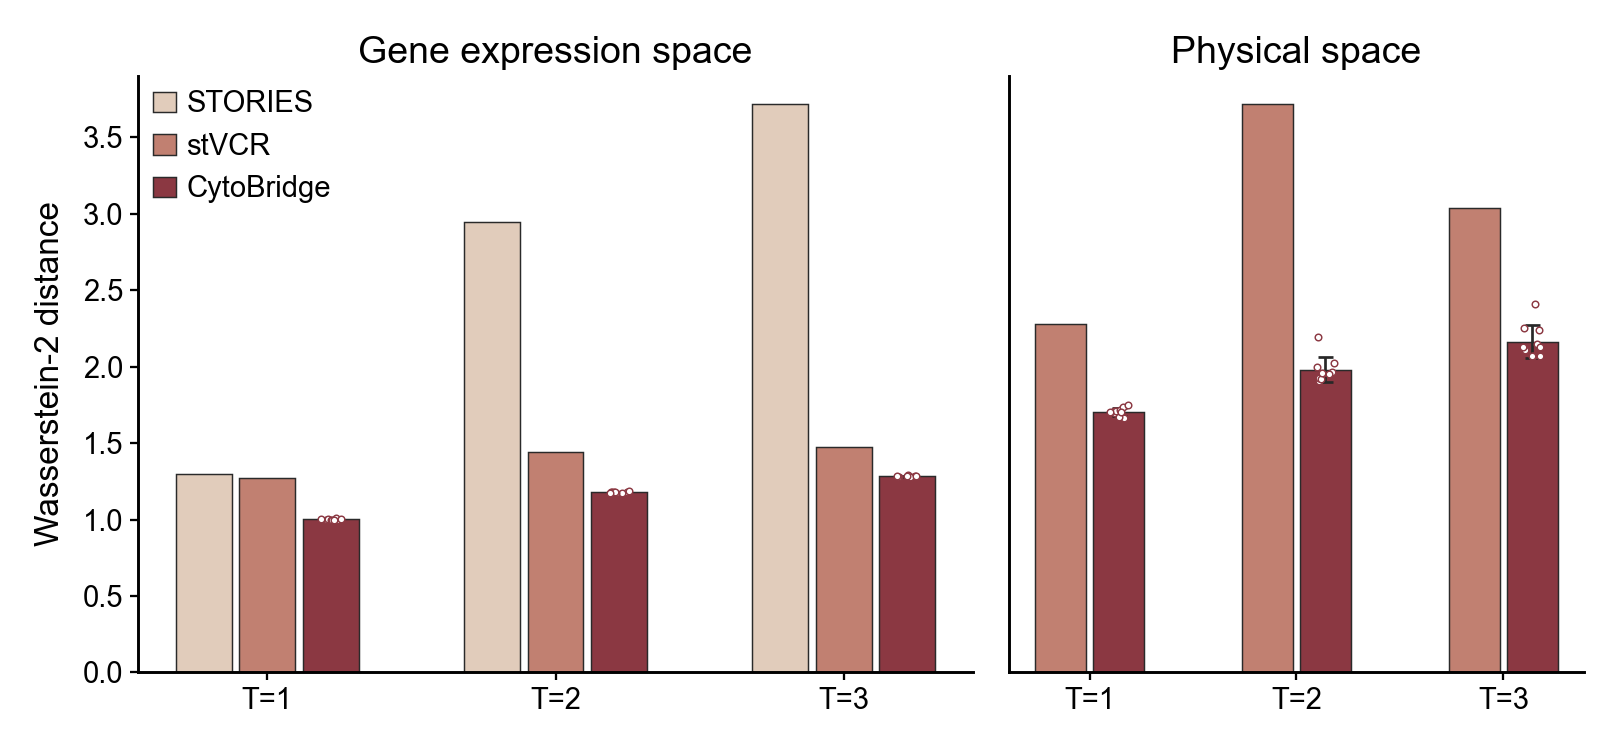

(PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/main_figure_2_numerical_reader_r2/figures/panel_e.pdf'),
 PosixPath('/data/cytobridge/projects/CytoBridge-ST-1104/runs/package-reader-repair-20260907/simulation_nonspatial/notebook_project/outputs/main_figure_2_numerical_reader_r2/figures/panel_e.png'))

In [7]:
from reproduction.agist.inputs import main_figure_2_from_evaluation
from reproduction.agist.main_figure import draw_distance_panels

figure_data = main_figure_2_from_evaluation(distances)
display(figure_data.summary)
pdf, png = draw_distance_panels(figure_data, figures)
display(Image(filename=str(png), width=720))
pdf, png